# Modes of asymmetry: from U(1) to SU(2)

**Manuscript map.** Sec. III C, Fig. 4, Eqs. (48)-(53); the non-Abelian
extension uses the Wigner-Eckart theorem in the coupled-spin (Schur)
basis.

Before studying symmetry Mpemba effects, this notebook visualizes the
mode decomposition itself.

**Part I — U(1).** For rotations generated by the total magnetization
$S_z$ on $N_s=3$ qubits, operator space splits into charges
$\mu\in\{0,\pm1,\pm2,\pm3\}$, and a matrix element
$|m\rangle\langle m'|$ carries the single label $\mu = m-m'$. We prepare

$$
|\varphi(\theta)\rangle
=\bigotimes_{n=1}^{N_s} e^{-i\theta\sigma_y/2}|0\rangle_n,
\qquad \theta\in\{0,\pi/4,\pi/2\},
$$

and inspect which modes are populated.

**Part II — SU(2).** For the full rotation group generated by the
collective spin $\mathbf J=\tfrac12\sum_n\boldsymbol\sigma_n$, operator
space decomposes into *irreducible tensor operators of rank
$\mu\in\{0,\dots,N_s\}$*. On $N_s=4$ qubits we mirror the U(1) construction
one qubit per singlet pair,

$$
|\varphi(\theta)\rangle
=\bigotimes_{k=1}^{N_s/2}\bigl(e^{-i\theta\sigma_y/2}\otimes\mathbb 1\bigr)|\xi\rangle_k,
\qquad |\xi\rangle=(|01\rangle-|10\rangle)/\sqrt 2,
$$

tilting between the SU(2)-invariant singlet product and a superposition
that spreads over every total-spin sector, and watch how the weight
spreads over ranks $\mu$.


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_HERE = Path.cwd().resolve()
for _candidate in [_HERE, *_HERE.parents]:
    if (_candidate / "tools" / "notebook_utils.py").exists():
        _TOOLS_DIR = _candidate / "tools"
        break
else:
    raise RuntimeError(
        "Could not locate tools/notebook_utils.py from cwd or its parents."
    )
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. Modes as blocks of operator space

For a system of $N_s$ qubits with $U(1)$ symmetry generated by total
magnetization $S_z$, the operator space splits into charge sectors
$\mu\in\{-N_s,\dots,N_s\}$. Labelling every computational-basis state
by its magnetization $m$ and a multiplicity index $k$ enumerating the
$\binom{N_s}{m}$ states in the fixed-$m$ sector, an elementary
mode-$\mu$ operator has the form

$$
|m,k\rangle\langle m-\mu,\,k'|,\qquad \mu = m - m'.
$$

Sorting the computational basis first by $m$ and then by $k$ makes the
block structure visually explicit: the $\mu=0$ sector is
block-diagonal (each block is one magnetization sector of size
$\binom{N_s}{m}$), and every $\mu\ne0$ sector is a clean off-diagonal
band shifting between magnetization sectors.


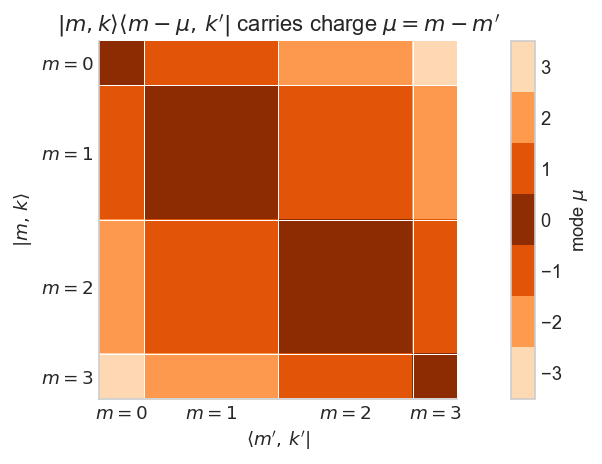

In [2]:
from matplotlib.colors import BoundaryNorm, ListedColormap

N_SITES = 3
charges = np.arange(-N_SITES, N_SITES + 1)

# Orange intensity peaks at mu = 0 (most saturated) and fades symmetrically
# with |mu|, so that mu and -mu share the same shade.
_intensity = 0.95 - 0.75 * (np.abs(charges) / N_SITES)
mode_colors = plt.colormaps["Oranges"](_intensity)
mode_cmap = ListedColormap(mode_colors)
mode_norm = BoundaryNorm(np.arange(-N_SITES - 0.5, N_SITES + 1), mode_cmap.N)

# Sort the computational basis first by magnetization m = w(bit-string)
# and then by the original index (playing the role of the multiplicity
# label k inside each fixed-m sector). In this ordering the mu = 0
# sector is block-diagonal and every mu != 0 sector is a clean band.
hamming = nu.hamming_weights(N_SITES)
basis_order = np.argsort(hamming, kind="stable")
sector_sizes = np.bincount(hamming, minlength=N_SITES + 1)
sector_boundaries = np.cumsum(sector_sizes)[:-1] - 0.5
sector_centers = np.cumsum(sector_sizes) - sector_sizes / 2 - 0.5
sector_labels = [rf"$m={w}$" for w in range(N_SITES + 1)]

mode_assignment = hamming[:, None] - hamming[None, :]


def draw_sector_boundaries(ax, color="white", linewidth=0.6):
    for boundary in sector_boundaries:
        ax.axhline(boundary, color=color, linewidth=linewidth)
        ax.axvline(boundary, color=color, linewidth=linewidth)


def label_sectors(ax):
    ax.set_xticks(sector_centers)
    ax.set_xticklabels(sector_labels)
    ax.set_yticks(sector_centers)
    ax.set_yticklabels(sector_labels)


fig, (ax, cax) = plt.subplots(
    1, 2, figsize=(5.4, 4.0),
    gridspec_kw={"width_ratios": [1, 0.05]},
)
ax.imshow(
    mode_assignment[np.ix_(basis_order, basis_order)].astype(float),
    cmap=mode_cmap,
    norm=mode_norm,
    interpolation="nearest",
)
draw_sector_boundaries(ax)
label_sectors(ax)
ax.set(
    xlabel=r"$\langle m',\,k'|$",
    ylabel=r"$|m,\,k\rangle$",
    title=r"$|m,k\rangle\langle m-\mu,\,k'|$ carries charge $\mu = m-m'$",
)
ax.grid(False)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=mode_norm, cmap=mode_cmap),
    cax=cax, ticks=charges,
)
cbar.set_label(r"mode $\mu$")
fig.tight_layout()
plt.show()


## 2. A tilted family of product states

With the mode structure in hand, we can pick a concrete family and ask
which blocks each state populates. The $U(1)$ twirl deletes matrix
elements connecting different magnetization sectors, so the state
recovers from its mode components:

$$
\rho=\sum_{\mu=-N_s}^{N_s}\rho^{(\mu)},\qquad
\mathcal G[\rho]=\rho^{(0)}.
$$


In [3]:
THETAS = [0, np.pi / 4, np.pi / 2]


def tilted_product_state(theta):
    ket = np.array([1.0 + 0j, 0j])
    single_qubit = la.expm(-0.5j * theta * nu.Y) @ ket
    state = nu.kron_all([single_qubit] * N_SITES)
    return np.outer(state, state.conj())


states = [tilted_product_state(theta) for theta in THETAS]
modes = [nu.asymmetry_modes_u1(state, N_SITES) for state in states]

for state, mode_dict in zip(states, modes):
    reconstructed = sum(mode_dict.values())
    assert np.allclose(reconstructed, state)
    assert np.allclose(mode_dict[0], nu.u1_twirl(state, N_SITES))


## 3. Rescaled mode weights

As in Eq. (53), we use the trace norm of each mode and normalize it by
the corresponding weight of the maximally tilted state:

$$
p_\theta^{(\mu)}
=\frac{\|\rho_\theta^{(\mu)}\|_1}
       {\|\rho_{\pi/2}^{(\mu)}\|_1}.
$$


In [4]:
raw_weights = np.array([
    [np.sum(la.svdvals(mode_dict[charge])) for charge in charges]
    for mode_dict in modes
])
rescaled_weights = raw_weights / raw_weights[-1]

print("Rows: theta = 0, pi/4, pi/2; columns: mu = -3,...,3")
print(rescaled_weights)


Rows: theta = 0, pi/4, pi/2; columns: mu = -3,...,3
[[0.      0.      0.      1.      0.      0.      0.     ]
 [0.35355 0.5     0.73249 1.      0.73249 0.5     0.35355]
 [1.      1.      1.      1.      1.      1.      1.     ]]


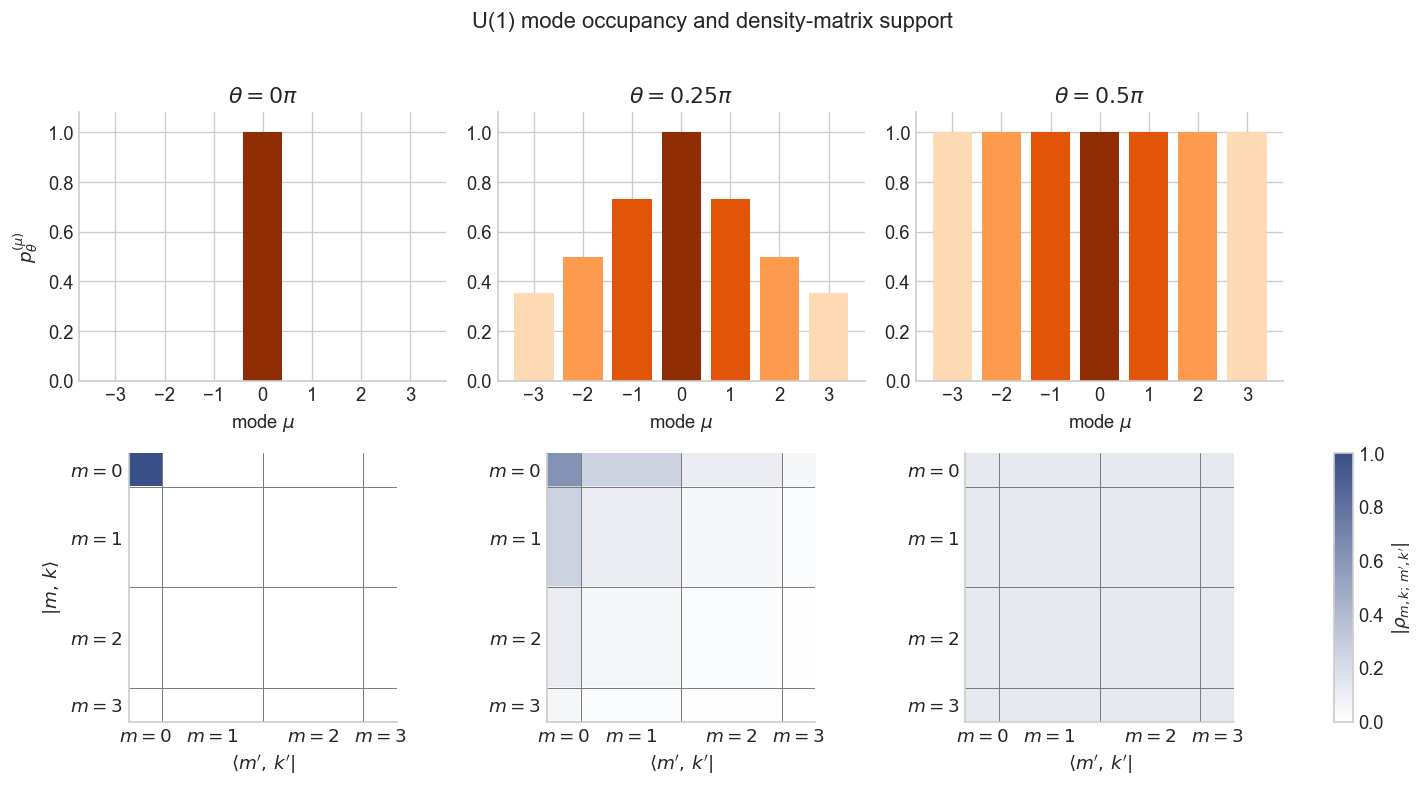

In [5]:
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6.4),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.05]},
)
axes[0, 3].axis("off")  # bar row has no colorbar

# Linear white -> BLUE gradient for |rho|, aligned with the notebook
# palette and visually distinct from the orange mu-charge scale.
density_cmap = LinearSegmentedColormap.from_list("density", ["white", BLUE])
density_vmax = max(np.abs(state).max() for state in states)

for column, (theta, state, weights_theta) in enumerate(
    zip(THETAS, states, rescaled_weights)
):
    axes[0, column].bar(charges, weights_theta, color=mode_colors)
    axes[0, column].set(
        title=fr"$\theta={theta / np.pi:.2g}\pi$",
        xlabel=r"mode $\mu$",
        ylabel=r"$p_\theta^{(\mu)}$" if column == 0 else None,
        ylim=(0, 1.08),
        xticks=charges,
    )

    im = axes[1, column].imshow(
        np.abs(state)[np.ix_(basis_order, basis_order)],
        cmap=density_cmap,
        vmin=0.0,
        vmax=density_vmax,
    )
    draw_sector_boundaries(axes[1, column], color="#7C7C7C")
    label_sectors(axes[1, column])
    axes[1, column].set(
        xlabel=r"$\langle m',\,k'|$",
        ylabel=r"$|m,\,k\rangle$" if column == 0 else None,
    )
    axes[1, column].grid(False)

cbar = fig.colorbar(im, cax=axes[1, 3])
cbar.set_label(r"$|\rho_{m,k;\,m',k'}|$")

fig.suptitle("U(1) mode occupancy and density-matrix support", y=1.02)
fig.tight_layout()
plt.show()


## Takeaway (U(1))

At $\theta=0$, only $\mu=0$ is present and the state is symmetric.
Tilting creates coherences between magnetization sectors, populating
nonzero modes. At $\theta=\pi/2$, every allowed charge is occupied. The
symmetry Mpemba mechanism will exploit the fact that different
nonzero-$\mu$ sectors can decay at different rates.


## 4. SU(2) modes: non-Abelian generalization

The U(1) argument above used a *single* charge label $\mu$ to organize
operator space. For a non-Abelian symmetry the group irreps are
higher-dimensional, but the manuscript's Eqs. (43)-(44) keep the same
label $\mu$ — it just enumerates the SU(2) irreps of the adjoint
action instead of U(1) characters.

**Irreducible tensor operators.** For SU(2), every operator on
$\mathcal H$ decomposes on the irreducible tensor basis of Eq. (43)-(44),

$$
X = \sum_{\mu,\,q}X^{(\mu,q)},
\qquad
X^{(\mu,q)}=\sum_\alpha \mathrm{Tr}\!\bigl[T_\alpha^{(\mu,q)}X^\dagger\bigr]\,
T_\alpha^{(\mu,q)},
$$

with $\mu\in\{0,1,\dots,N_s\}$ the SU(2) irrep label (the *asymmetry
mode*), $q\in\{-\mu,\dots,\mu\}$ running over its $d_\mu=2\mu+1$
sublevels, and $\alpha=1,\dots,m_\mu$ the operator-space multiplicity
index. The tensors satisfy the standard spherical relations

$$
[J_z,\,T_\alpha^{(\mu,q)}] = q\,T_\alpha^{(\mu,q)},
\quad
[J_\pm,\,T_\alpha^{(\mu,q)}]
= \sqrt{\mu(\mu+1)-q(q\pm 1)}\,T_\alpha^{(\mu,q\pm 1)},
$$

so each $\mu$-sector is closed under SU(2) and irreducible of
dimension $2\mu+1$. The mode projectors are the spectral projectors
of the **conjugation Casimir**

$$
\mathcal C(X):=\sum_{a\in\{x,y,z\}}\bigl[J_a,[J_a,X]\bigr],
\qquad
\mathcal C\bigl|_{\mu\text{-sector}}=\mu(\mu+1)\,\mathbb 1.
$$

Consistent with Eq. (35), the SU(2) twirl

$$
\mathcal G[\rho]=\int dU\;U\rho U^\dagger=\rho^{(\mu=0)}
$$

is the projection onto the trivial ($\mu=0$) irrep — the direct
generalization of the U(1) $\mu=0$ sector.

**Schur (coupled-spin) view.** Peter-Weyl / Schur-Weyl decomposes
the Hilbert space into total-spin blocks,

$$
\mathcal H=\bigoplus_j\;V_j\otimes M_j,
\qquad
\dim V_j=2j+1,\quad m_j:=\dim M_j,
$$

with basis $|j,m,\alpha\rangle$ labelled by total spin $j$, magnetic
quantum number $m$, and Hilbert-space multiplicity index $\alpha$
(overloading the letter $\alpha$ with the operator multiplicity of
$T_\alpha^{(\mu,q)}$ above is standard; the two live in different
spaces and context always disambiguates). The **Wigner-Eckart
theorem** factors matrix elements of an irreducible tensor,

$$
\langle j,m,\alpha\,|\,T_\alpha^{(\mu,q)}\,|\,j',m',\alpha'\rangle
=\langle j\,m\,|\,j'\,m';\,\mu\,q\rangle\;
\langle j,\alpha\,\|T^{(\mu)}\|\,j',\alpha'\rangle,
\qquad q\equiv m-m',
$$

so the operator $|j,m,\alpha\rangle\langle j',m',\alpha'|$ is
supported only on modes

$$
|j-j'|\le\mu\le j+j'.
$$

Two immediate consequences:

- the $\mu=0$ trivial irrep (the SU(2)-invariant operators) lives
  entirely in the diagonal-in-$j$ Schur blocks; the twirl $\mathcal G$
  retains those and averages over the irrep sublevels;
- modes $\mu\ge 1$ carry coherences between distinct total-spin
  sectors, up to the block-dependent ceiling $\mu_{\max}=j+j'$.

**Mode decomposition of a density matrix.** Applied to a state
$\rho$, the spectral projectors of $\mathcal C$ split it into a sum
of mode components

$$
\rho = \sum_{\mu=0}^{N_s}\rho^{(\mu)},
\qquad
\rho^{(\mu)} = \sum_q\rho^{(\mu,q)}
             = \sum_{q,\alpha}\mathrm{Tr}\!\bigl[T_\alpha^{(\mu,q)}\rho^\dagger\bigr]\,
               T_\alpha^{(\mu,q)},
$$

directly parallel to Eqs. (43)-(44) and the U(1) decomposition of
Section 1. Each $\rho^{(\mu)}$ inherits Hermiticity from $\rho$; the
$\mu=0$ mode is the SU(2) twirl, and the modes $\mu\ge 1$ collect
the asymmetric content that the twirl deletes. By Eq. (48) their
trace norms are individually monotones under any SU(2)-covariant
map.

**Structure of each mode in the CG basis.** Because $\rho^{(\mu)}$
is an irreducible tensor operator of rank $\mu$, Wigner-Eckart
factors every one of its matrix elements into a Clebsch-Gordan
coefficient and a reduced matrix element,

$$
\bigl[\rho^{(\mu)}\bigr]_{j\,m\,\alpha;\,j'\,m'\,\alpha'}
=\underbrace{\langle j\,m\,|\,j'\,m';\,\mu\,q\rangle}_{\text{CG (magnetic)}}\;
 \underbrace{\bigl\langle j,\alpha\,\|\rho^{(\mu)}\|\,j',\alpha'\bigr\rangle}_{\text{reduced m.e.}},
\qquad q\equiv m-m'.
$$

The CG piece is a purely group-theoretic pattern in the
$(2j+1)\times(2j'+1)$ magnetic plane; it vanishes unless
$|j-j'|\le\mu\le j+j'$ (block-level triangle) and $|q|\le\mu$
(magnetic band), the two Wigner-Eckart selection rules. All the
physics of $\rho$ is packaged into the **reduced matrix element**
$\langle j,\alpha\|\rho^{(\mu)}\|j',\alpha'\rangle$, a single complex
number independent of $m,m',q$. Inside every $(j,j')$ Schur block
this makes $\rho^{(\mu)}$ a *rank-one tensor* in the factorization
$V_j\otimes V_{j'}^*\otimes M_j\otimes M_{j'}^*$: one CG pattern in
the magnetic plane multiplied by an $m_j\times m_{j'}$
reduced-matrix-element block in the multiplicity plane. Different
$(\alpha,\alpha')$ tiles of the same Schur block therefore share the
same magnetic CG pattern and differ only in their reduced-matrix-
element weight.

**The $\mu=0$ (scalar) mode.** The selection rules collapse to
$j=j'$, $q=0$, $m=m'$ with
$\langle j\,m\,|\,j\,m;\,0\,0\rangle=\delta_{mm'}/\sqrt{2j+1}$, so

$$
\rho^{(0)}
= \bigoplus_j\;\frac{\mathbb 1_{V_j}}{2j+1}\otimes A_j,
\qquad
A_j = \mathrm{tr}_{V_j}\!\bigl(\rho\big|_{V_j\otimes M_j}\bigr),
$$

which is exactly $\mathcal G[\rho]$ of Eq. (35): block-diagonal in
$j$, proportional to the identity inside each SU(2) irrep $V_j$, and
freely determined by a Hermitian $m_j\times m_j$ matrix on every
multiplicity space $M_j$.

We take $N_s=4$ qubits so the singlet product is well defined, and
sort the Schur basis by $j$. To visualise the structure of each mode
$\rho^{(\mu)}$ we plot **one panel per $\mu\in\{0,\dots,N_s\}$**:
each panel colours the Schur cell with row $(j,m,\alpha)$ and column
$(j',m',\alpha')$ by the **Wigner 3j-symbol**

$$
\begin{pmatrix} j' & \mu & j \\ m' & q & -m \end{pmatrix},
\qquad q\equiv m-m',
$$

which absorbs the $\sqrt{2j+1}$ normalization and the
$(-1)^{j'-\mu+m}$ phase out of the raw CG factor
$\langle j\,m\,|\,j'\,m';\,\mu\,q\rangle$ appearing in the
Wigner-Eckart formula above. A cyclic permutation of its columns
shows the 3j-symbol is invariant under
$(j,m,\alpha)\leftrightarrow(j',m',\alpha')$, so **the resulting
panels are transpose-symmetric** — the picture you'd expect from a
Hermitian mode component $\rho^{(\mu)}=[\rho^{(\mu)}]^\dagger$.
Every rank-$\mu$ operator carries this same group-theoretic pattern
inside any $(j,j')$ Schur block; the reduced matrix elements
$\langle j,\alpha\|\rho^{(\mu)}\|j',\alpha'\rangle$ only reweight the
$m_j\times m_{j'}$ multiplicity tiles on top of it. A blue/white/orange
scale keeps the signed structure of the 3j-symbol visible.

Reading the panels from left to right:

- $\mu=0$ (SU(2)-invariant): the 3j collapses to
  $\delta_{jj'}\delta_{mm'}/\sqrt{(2j+1)}$; the pattern lights up
  only on the multiplicity-diagonal of every $j=j'$ block. **Those
  cells (and only those) survive the SU(2) twirl $\mathcal G$**,
  mirroring the $\mu=0$ diagonal of Section 1.
- $\mu=1,2,3$: progressively more Schur blocks are activated,
  following the triangle rule $|j-j'|\le\mu\le j+j'$ together with
  the magnetic constraint $|q|\le\mu$. Signs alternate along each
  $q$-band as prescribed by the Racah recursion, symmetrically on
  either side of the main diagonal.
- $\mu=N_s$: the pattern is confined to the single
  $(N_s/2,N_s/2)$ Schur block and spans its full $|q|\le N_s$ band.

The companion bar chart records the *mode multiplicity*

$$
m_\mu^{\mathrm{op}}
=\sum_{j,j'} m_j\,m_{j'}\;\mathbf 1\!\bigl[\,|j-j'|\le\mu\le j+j'\,\bigr],
$$

i.e. the number of independent copies of the mode-$\mu$ irrep sitting
inside operator space, following Wigner-Eckart. It satisfies the
completeness sum
$\sum_\mu (2\mu+1)\,m_\mu^{\mathrm{op}} = d^2 = 2^{2N_s}$, and its
shape tells us at a glance which modes dominate the decomposition.


/var/folders/8t/n3799d756j75dswk930zl0600000gn/T/ipykernel_97589/2050440097.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


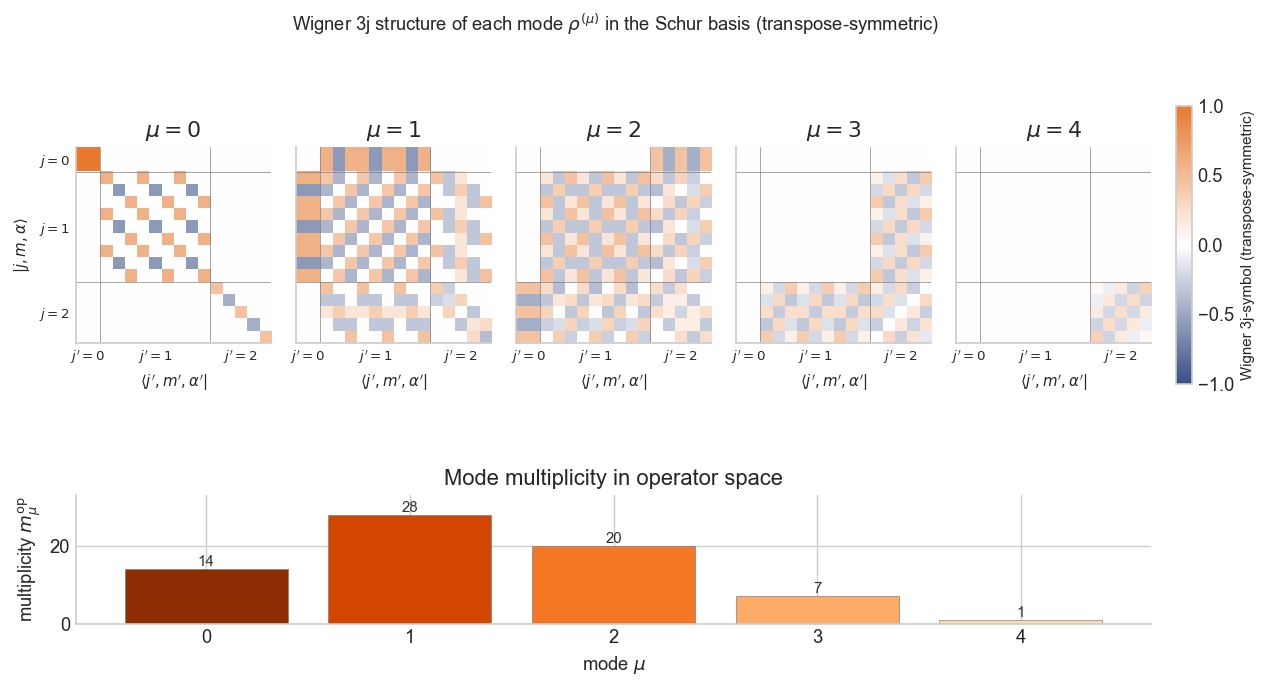

Total-spin sectors and their sizes (2j+1) * m_j:
  j = 0.0: multiplicity 2, irrep dim 1, sector size 2
  j = 1.0: multiplicity 3, irrep dim 3, sector size 9
  j = 2.0: multiplicity 1, irrep dim 5, sector size 5

Mode multiplicities in operator space (Wigner-Eckart bookkeeping):
  mu = 0: m^op_mu =  14  ->  dim =  14
  mu = 1: m^op_mu =  28  ->  dim =  84
  mu = 2: m^op_mu =  20  ->  dim = 100
  mu = 3: m^op_mu =   7  ->  dim =  49
  mu = 4: m^op_mu =   1  ->  dim =   9
  total: sum_mu (2 mu + 1) m^op_mu = 256 = d^2


In [6]:
from math import factorial

from matplotlib.colors import (
    BoundaryNorm,
    LinearSegmentedColormap,
    ListedColormap,
    TwoSlopeNorm,
)

N_SU2 = 4
basis_su2, paths_by_spin_su2 = nu.su2_schur_basis(
    N_SU2, convention="sequential"
)

# Ordering of the Schur basis: outer loop over 2j, then over multiplicity
# path, then over the magnetic index m. Record the total spin j *and*
# the magnetic quantum number m attached to every Schur column so we
# can both draw the (j, j') block structure and evaluate CG amplitudes
# for every mu-sector.
schur_spins = []
schur_m = []
sector_starts_su2 = []
sector_sizes_su2 = []
_offset = 0
for spin_twice in sorted(paths_by_spin_su2):
    multiplicity = len(paths_by_spin_su2[spin_twice])
    irrep_dimension = spin_twice + 1
    block_size = multiplicity * irrep_dimension
    schur_spins.extend([spin_twice / 2] * block_size)
    for _ in range(multiplicity):
        for m_twice in range(-spin_twice, spin_twice + 1, 2):
            schur_m.append(m_twice / 2)
    sector_starts_su2.append(_offset)
    sector_sizes_su2.append(block_size)
    _offset += block_size
schur_spins = np.asarray(schur_spins)
schur_m = np.asarray(schur_m)
sector_starts_su2 = np.asarray(sector_starts_su2)
sector_sizes_su2 = np.asarray(sector_sizes_su2)
sector_boundaries_su2 = (sector_starts_su2 + sector_sizes_su2)[:-1] - 0.5
sector_centers_su2 = sector_starts_su2 + sector_sizes_su2 / 2 - 0.5
sector_labels_su2_ket = [
    fr"$j={int(spin_twice/2)}$"
    for spin_twice in sorted(paths_by_spin_su2)
]
sector_labels_su2_bra = [
    fr"$j'={int(spin_twice/2)}$"
    for spin_twice in sorted(paths_by_spin_su2)
]

# Rank palette: peak intensity at mu=0 (scalar), fading as mu grows.
ranks_su2 = np.arange(N_SU2 + 1)
_rank_intensity = 0.95 - 0.75 * (ranks_su2 / N_SU2)
rank_colors_su2 = plt.colormaps["Oranges"](_rank_intensity)
rank_cmap_su2 = ListedColormap(rank_colors_su2)
rank_norm_su2 = BoundaryNorm(
    np.arange(-0.5, N_SU2 + 1.5), rank_cmap_su2.N
)


# --- Clebsch-Gordan amplitude via the Racah formula ---------------
# Wigner-Eckart says
#     <j_a m_a alpha | T^{(mu, q)} | j_b m_b alpha'>
#         = <j_a m_a | j_b m_b ; mu q>  <j_a alpha || T^{(mu)} || j_b alpha'>.
# The CG piece is state-independent and identical across all
# multiplicity tiles inside a single Schur block, so plotting it
# panel-by-panel exposes the group-theoretic template that every
# rho^{(mu)} inherits.
def _cg_racah(j_bra, m_bra, mu, q, j_ket, m_ket):
    """CG amplitude <j_ket m_ket | j_bra m_bra ; mu q> (integer spins)."""
    j1, m1 = int(round(j_bra)), int(round(m_bra))
    j2, m2 = int(round(mu)), int(round(q))
    j, m = int(round(j_ket)), int(round(m_ket))
    if m1 + m2 != m:
        return 0.0
    if j < abs(j1 - j2) or j > j1 + j2:
        return 0.0
    if abs(m1) > j1 or abs(m2) > j2 or abs(m) > j:
        return 0.0
    prefactor = (
        (2 * j + 1)
        * factorial(j + j1 - j2)
        * factorial(j - j1 + j2)
        * factorial(j1 + j2 - j)
        / factorial(j1 + j2 + j + 1)
    ) * (
        factorial(j + m) * factorial(j - m)
        * factorial(j1 - m1) * factorial(j1 + m1)
        * factorial(j2 - m2) * factorial(j2 + m2)
    )
    prefactor = prefactor**0.5
    k_min = max(0, j2 - j - m1, j1 - j + m2)
    k_max = min(j1 + j2 - j, j1 - m1, j2 + m2)
    total = 0.0
    for k in range(k_min, k_max + 1):
        denom = (
            factorial(k)
            * factorial(j1 + j2 - j - k)
            * factorial(j1 - m1 - k)
            * factorial(j2 + m2 - k)
            * factorial(j - j2 + m1 + k)
            * factorial(j - j1 - m2 + k)
        )
        total += (-1) ** k / denom
    return prefactor * total


cg_matrices = {}
for mu_val in ranks_su2:
    mu_int = int(mu_val)
    n = len(schur_spins)
    mat = np.zeros((n, n))
    for a in range(n):
        j_a, m_a = schur_spins[a], schur_m[a]
        for b in range(n):
            j_b, m_b = schur_spins[b], schur_m[b]
            q = m_a - m_b
            if abs(j_a - j_b) > mu_int or mu_int > j_a + j_b:
                continue
            if abs(q) > mu_int:
                continue
            mat[a, b] = _cg_racah(j_b, m_b, mu_int, q, j_a, m_a)
    cg_matrices[mu_int] = mat


# Rewrite the plotted quantity as the Wigner 3j-symbol, which absorbs the
# CG normalization sqrt(2j+1) and the (-1)^{j'-mu+m} phase into a shape
# that IS transpose-symmetric under (a, b) <-> (b, a). This restores the
# expected Hermitian-symmetric picture of every mode rho^{(mu)} without
# hiding the sign structure of the coupling.
threej_matrices = {}
for mu_val in ranks_su2:
    mu_int = int(mu_val)
    n = len(schur_spins)
    tj = np.zeros((n, n))
    cg_mat = cg_matrices[mu_int]
    for a in range(n):
        j_a = int(round(schur_spins[a]))
        m_a = int(round(schur_m[a]))
        for b in range(n):
            if cg_mat[a, b] == 0.0:
                continue
            j_b = int(round(schur_spins[b]))
            phase = (-1) ** ((j_b - mu_int + m_a) % 2)
            tj[a, b] = cg_mat[a, b] * phase / np.sqrt(2 * j_a + 1)
    threej_matrices[mu_int] = tj

for mu_int, tj in threej_matrices.items():
    symmetry_error = float(np.abs(tj - tj.T).max())
    assert symmetry_error < 1e-12, (
        f"3j panel is not transpose-symmetric for mu={mu_int}: "
        f"|tj - tj.T|_inf = {symmetry_error:.3e}"
    )


# Mode multiplicities in operator space (Wigner-Eckart bookkeeping).
_mult_by_spin = {
    spin_twice / 2: len(paths)
    for spin_twice, paths in paths_by_spin_su2.items()
}
rank_multiplicities_su2 = np.zeros(N_SU2 + 1, dtype=int)
for j_ket, m_ket in _mult_by_spin.items():
    for j_bra, m_bra in _mult_by_spin.items():
        low = int(abs(j_ket - j_bra))
        high = int(j_ket + j_bra)
        rank_multiplicities_su2[low : high + 1] += m_ket * m_bra
assert sum(
    (2 * mu + 1) * m for mu, m in enumerate(rank_multiplicities_su2)
) == (2**N_SU2) ** 2


# Diverging colormap for signed 3j amplitudes, anchored on the palette.
cg_cmap = LinearSegmentedColormap.from_list(
    "cg_signed", [BLUE, "white", ORANGE]
)
cg_vmax = max(np.abs(m).max() for m in threej_matrices.values())
cg_vmax = max(cg_vmax, 1e-3)
cg_norm = TwoSlopeNorm(vmin=-cg_vmax, vcenter=0, vmax=cg_vmax)


def draw_su2_boundaries(ax, color="#7C7C7C", linewidth=0.4):
    for boundary in sector_boundaries_su2:
        ax.axhline(boundary, color=color, linewidth=linewidth)
        ax.axvline(boundary, color=color, linewidth=linewidth)


# Layout: 5 mu panels in row 1 (one per mode), bar chart in row 2.
n_panels = N_SU2 + 1
fig = plt.figure(figsize=(12, 5.6))
gs = fig.add_gridspec(
    2, n_panels + 1,
    height_ratios=[2.6, 1.2],
    width_ratios=[1] * n_panels + [0.08],
    hspace=0.55, wspace=0.15,
)

for col_idx, mu_val in enumerate(ranks_su2):
    mu_int = int(mu_val)
    ax = fig.add_subplot(gs[0, col_idx])
    im = ax.imshow(
        threej_matrices[mu_int],
        cmap=cg_cmap,
        norm=cg_norm,
        interpolation="nearest",
    )
    draw_su2_boundaries(ax)
    ax.set(title=fr"$\mu={mu_int}$", xticks=[], yticks=[])
    ax.grid(False)
    ax.set_xticks(sector_centers_su2)
    ax.set_xticklabels(sector_labels_su2_bra, fontsize=8)
    ax.set_xlabel(r"$\langle j',m',\alpha'|$", fontsize=9)
    if col_idx == 0:
        ax.set_yticks(sector_centers_su2)
        ax.set_yticklabels(sector_labels_su2_ket, fontsize=8)
        ax.set_ylabel(r"$|j,m,\alpha\rangle$", fontsize=9)

cax = fig.add_subplot(gs[0, n_panels])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"Wigner 3j-symbol (transpose-symmetric)", fontsize=9)

ax_bar = fig.add_subplot(gs[1, :n_panels])
ax_bar.bar(
    ranks_su2, rank_multiplicities_su2,
    color=rank_colors_su2, edgecolor="#7C7C7C", linewidth=0.4,
)
for mu, mult in enumerate(rank_multiplicities_su2):
    ax_bar.text(
        mu, mult, str(int(mult)),
        ha="center", va="bottom", fontsize=9, color="#333333",
    )
ax_bar.set(
    xlabel=r"mode $\mu$",
    ylabel=r"multiplicity $m^{\mathrm{op}}_\mu$",
    title="Mode multiplicity in operator space",
    xticks=ranks_su2,
)
ax_bar.set_ylim(0, rank_multiplicities_su2.max() * 1.18)

fig.suptitle(
    r"Wigner 3j structure of each mode $\rho^{(\mu)}$ in the Schur basis (transpose-symmetric)",
    y=1.02, fontsize=11,
)
fig.tight_layout()
plt.show()

# Reference summary of the coupled-spin decomposition.
print("Total-spin sectors and their sizes (2j+1) * m_j:")
for spin_twice, size in zip(sorted(paths_by_spin_su2), sector_sizes_su2):
    print(
        f"  j = {spin_twice / 2:.1f}: multiplicity {len(paths_by_spin_su2[spin_twice])}, "
        f"irrep dim {spin_twice + 1}, sector size {size}"
    )
print()
print("Mode multiplicities in operator space (Wigner-Eckart bookkeeping):")
for mu, mult in enumerate(rank_multiplicities_su2):
    dim = (2 * mu + 1) * int(mult)
    print(f"  mu = {mu}: m^op_mu = {int(mult):3d}  ->  dim = {dim:3d}")
print(f"  total: sum_mu (2 mu + 1) m^op_mu = {(2**N_SU2)**2} = d^2")


In [7]:
# --- Sanity check: sum_mu P_mu = identity on operator space --------
# The mode-projection superoperators partition operator space, so
# summing them reconstructs any input operator: sum_mu rho^(mu) = rho.
# Section 5 verifies this on the tilted states; here we check the
# SU(2)-invariant reference rho = I (which lives entirely in mu = 0).
mode_bases_su2 = nu.su2_operator_irrep_bases(N_SU2)
identity_op = np.eye(2**N_SU2, dtype=complex)
reconstructed_id = sum(
    nu.su2_operator_mode(identity_op, mode_bases_su2[int(mu)])
    for mu in ranks_su2
)
print(f"|sum_mu P_mu(I) - I|_inf = "
      f"{float(np.abs(reconstructed_id - identity_op).max()):.2e}")


|sum_mu P_mu(I) - I|_inf = 3.05e-14


## 5. A local-tilt family: the SU(2) analog of the U(1) tilted product

To watch the mode structure fill up we would like a single-parameter
family that behaves *in the same way* as the U(1) family of Section 2,
namely

$$
|\varphi_{U(1)}(\theta)\rangle
= \bigotimes_{n=1}^{N_s}\bigl(e^{-i\theta\sigma_y/2}|0\rangle_n\bigr):
$$

only the $\mu=0$ mode at $\theta=0$, and every allowed mode populated
with weight that decays monotonically with $|\mu|$ at $\theta=\pi/2$.

The direct SU(2) analog picks the singlet product as the invariant
reference and rotates *one qubit of every pair* by $e^{-i\theta\sigma_y/2}$:

$$
|\varphi(\theta)\rangle
= \bigotimes_{k=1}^{N_s/2}\bigl(e^{-i\theta\sigma_y/2}\otimes\mathbb 1\bigr)|\xi\rangle_k
= \bigotimes_{k=1}^{N_s/2}\bigl[\cos(\theta/2)|\xi\rangle_k
                              +\sin(\theta/2)|\phi^+\rangle_k\bigr],
$$

with $|\xi\rangle=(|01\rangle-|10\rangle)/\sqrt 2$ the singlet
($j_\text{pair}=0$) and $|\phi^+\rangle=(|00\rangle+|11\rangle)/\sqrt 2$
the $j_\text{pair}=1$ Bell state. Applying the rotation to only the
odd-indexed qubit of each pair breaks the local $U^{\otimes 2}$ symmetry
of the pair, so weight leaks smoothly from $j_\text{pair}=0$ into
$j_\text{pair}=1$ as $\theta$ grows.

- At $\theta=0$: a pure product of $N_s/2$ singlets, total spin $j=0$,
  SU(2)-invariant, so only the $\mu=0$ mode is populated.
- At intermediate $\theta$: each pair is a superposition of
  $j_\text{pair}=0$ and $j_\text{pair}=1$, and coupling $N_s/2$ pairs
  spreads the joint state over *every* total-spin sector
  $j\in\{0,1,\dots,N_s/2\}$. Every mode $\mu$ is populated with
  monotonically decreasing weight from $\mu=0$ outward, mirroring the
  U(1) profile of Section 2.
- At $\theta=\pi/2$: every mode $\mu\in\{0,\dots,N_s\}$ is populated
  and the rescaled weights of Eq. (54) equal one — the SU(2) analog of
  the "$|+\rangle^{\otimes N_s}$" endpoint of the U(1) family.

The construction is provided by `nu.su2_local_tilt_state`. (This is a
smoother alternative to the manuscript's Eq. (80) family
`nu.su2_tilted_state`, which superposes $|\xi\rangle^{\otimes N_s/2}$
with $|0\rangle^{\otimes N_s}$ directly; because that family populates
only the two extreme total-spin sectors $j=0$ and $j=N_s/2$, its
intermediate mode weights are shaped by the Clebsch-Gordan pattern of
the single $(N_s/2, N_s/2)$ Schur block and are *not* monotonic in
$\mu$.)


In [8]:
THETAS_SU2 = [0, np.pi / 4, np.pi / 2]


def su2_tilted_density(theta: float) -> np.ndarray:
    ket = nu.su2_local_tilt_state(N_SU2, theta)
    return np.outer(ket, ket.conj())


states_su2 = [su2_tilted_density(theta) for theta in THETAS_SU2]
mode_bases_su2 = nu.su2_operator_irrep_bases(N_SU2)

# The rank spectrum for N=4 spans mu = 0, 1, ..., N_s. Sanity-check that
# `su2_operator_irrep_bases` populated every entry.
assert set(mode_bases_su2.keys()) == set(int(mu) for mu in ranks_su2)

mode_projections_su2 = [
    {mu: nu.su2_operator_mode(state, mode_bases_su2[mu]) for mu in ranks_su2}
    for state in states_su2
]

# rho = sum_mu rho^{(mu)} and rho^{(0)} = SU(2) twirl of rho.
for state, projections in zip(states_su2, mode_projections_su2):
    reconstructed = sum(projections.values())
    assert np.allclose(reconstructed, state, atol=1e-9)
    twirl = nu.su2_twirl_exact(state, basis_su2, paths_by_spin_su2)
    assert np.allclose(projections[0], twirl, atol=1e-8)


## 6. Rescaled mode weights

We follow Eq. (54) of the manuscript verbatim: the mode weight of
$\rho_\theta$ is the trace norm of the $\mu$-mode, normalised to the
maximally tilted state,

$$
p_\theta^{(\mu)}
=\frac{\bigl\|\rho_\theta^{(\mu)}\bigr\|_1}
      {\bigl\|\rho_{\pi/2}^{(\mu)}\bigr\|_1}.
$$


In [9]:
raw_weights_su2 = np.array([
    [
        float(np.sum(la.svdvals(projections[mu])))
        for mu in ranks_su2
    ]
    for projections in mode_projections_su2
])
rescaled_weights_su2 = raw_weights_su2 / raw_weights_su2[-1]

print("Rows: theta = 0, pi/4, pi/2;  columns: mu = 0, 1, ..., N_s")
print(rescaled_weights_su2)


Rows: theta = 0, pi/4, pi/2;  columns: mu = 0, 1, ..., N_s
[[1.      0.      0.      0.      0.     ]
 [1.      0.75441 0.42916 0.20711 0.08579]
 [1.      1.      1.      1.      1.     ]]


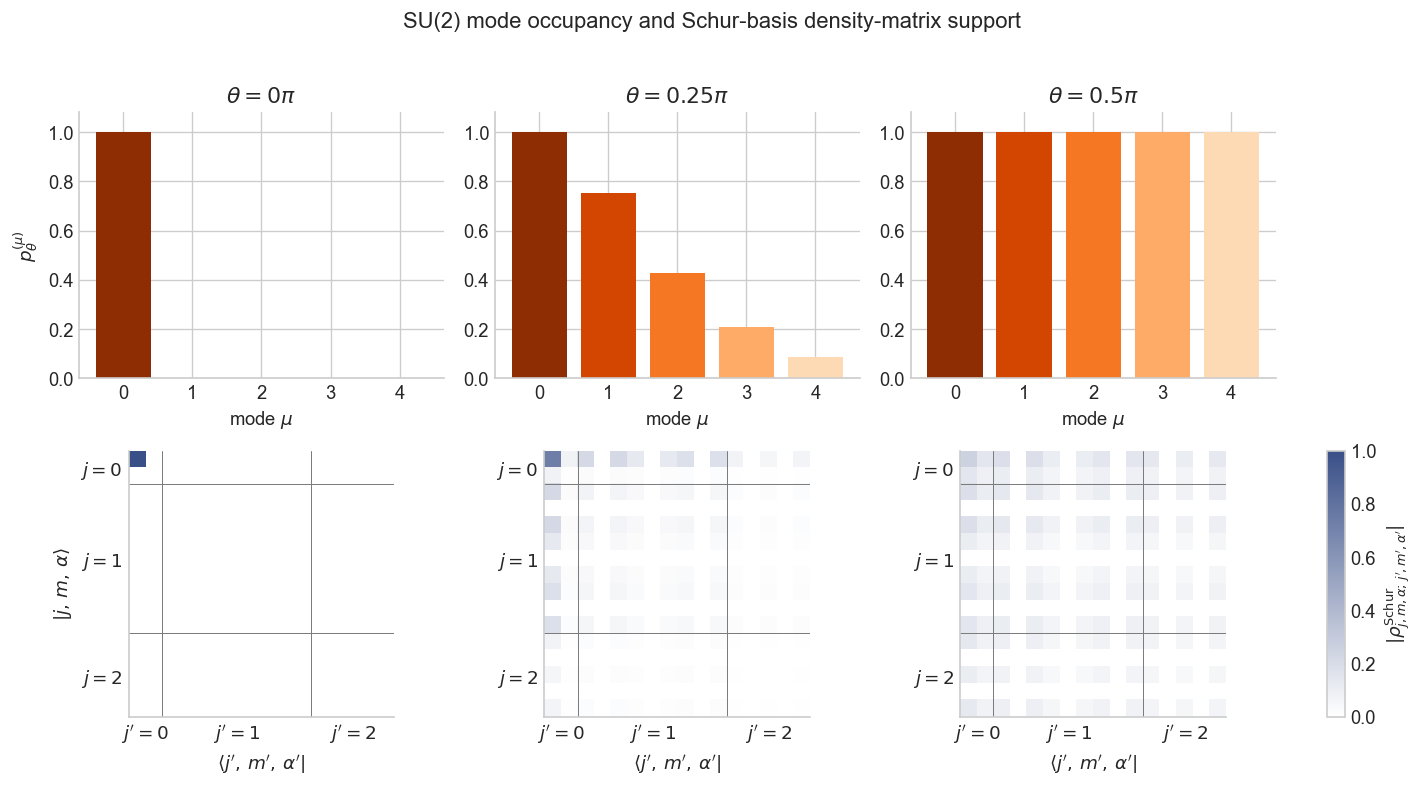

In [10]:
from matplotlib.colors import LinearSegmentedColormap

# Re-declare the density colormap so this SU(2) plot works even if the
# earlier U(1) density cell was not run in the current session.
density_cmap_su2 = LinearSegmentedColormap.from_list(
    "density_su2", ["white", BLUE]
)

# Transform each density to the Schur basis so the (j, j') block
# structure becomes visually explicit.
schur_densities_su2 = [
    nu.dagger(basis_su2) @ state @ basis_su2 for state in states_su2
]
density_vmax_su2 = max(np.abs(state).max() for state in schur_densities_su2)

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6.4),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.05]},
)
axes[0, 3].axis("off")  # bar row has no colorbar

for column, (theta, state_schur, weights_theta) in enumerate(
    zip(THETAS_SU2, schur_densities_su2, rescaled_weights_su2)
):
    axes[0, column].bar(ranks_su2, weights_theta, color=rank_colors_su2)
    axes[0, column].set(
        title=fr"$\theta={theta / np.pi:.2g}\pi$",
        xlabel=r"mode $\mu$",
        ylabel=r"$p_\theta^{(\mu)}$" if column == 0 else None,
        ylim=(0, 1.08),
        xticks=ranks_su2,
    )

    im = axes[1, column].imshow(
        np.abs(state_schur),
        cmap=density_cmap_su2,
        vmin=0.0,
        vmax=density_vmax_su2,
    )
    for boundary in sector_boundaries_su2:
        axes[1, column].axhline(boundary, color="#7C7C7C", linewidth=0.6)
        axes[1, column].axvline(boundary, color="#7C7C7C", linewidth=0.6)
    axes[1, column].set_xticks(sector_centers_su2)
    axes[1, column].set_xticklabels(sector_labels_su2_bra)
    axes[1, column].set_yticks(sector_centers_su2)
    axes[1, column].set_yticklabels(sector_labels_su2_ket)
    axes[1, column].set(
        xlabel=r"$\langle j',\,m',\,\alpha'|$",
        ylabel=r"$|j,\,m,\,\alpha\rangle$" if column == 0 else None,
    )
    axes[1, column].grid(False)

cbar = fig.colorbar(im, cax=axes[1, 3])
cbar.set_label(r"$|\rho^{\mathrm{Schur}}_{j,m,\alpha;\,j',m',\alpha'}|$")

fig.suptitle(
    "SU(2) mode occupancy and Schur-basis density-matrix support", y=1.02
)
fig.tight_layout()
plt.show()


## 7. The manuscript's Eq. (80) family

For completeness, we also compute the mode weights of the family used
in the manuscript — Eq. (80),

$$
|\varphi_{\text{Eq.\,80}}(\theta)\rangle
= \cos(\theta/2)\,|\xi\rangle^{\otimes N_s/2}
+ \sin(\theta/2)\,|0\rangle^{\otimes N_s},
$$

provided by `nu.su2_tilted_state`. The two endpoints match the
local-tilt family:

- $\theta=0$: pure singlet product, only $\mu=0$ populated.
- $\theta=\pi/2$: every mode $\mu\in\{0,\dots,N_s\}$ populated with
  rescaled weight one.

The *intermediate* profile is however qualitatively different. Because
Eq. (80) is a rank-two superposition supported entirely on the two
extreme total-spin sectors $j\in\{0,N_s/2\}$, each mode collects only
the specific Clebsch-Gordan and Wigner-Eckart contributions available
in the $(0,0)$, $(0,N_s/2)$ and $(N_s/2,N_s/2)$ Schur blocks:

- $\mu=0$ from the $(0,0)$ *and* $(N_s/2,N_s/2)$ diagonals;
- $\mu=N_s/2$ (=2 here) from the $(0,N_s/2)$ cross block *and* from
  the $(N_s/2,N_s/2)$ diagonal (extra weight);
- $\mu=1,3,\dots$ only from the $(N_s/2,N_s/2)$ diagonal.

The result is a spiky, *non-monotonic* profile — $\mu=2$ receives a
bump from the cross-block, while $\mu=1,3,4$ all share the small,
comparable CG weights of the $(N_s/2,N_s/2)$ block.



Rows: theta = 0, pi/4, pi/2;  columns: mu = 0, 1, ..., N_s
[[1.      0.      0.      0.      0.     ]
 [1.      0.29289 0.57959 0.29289 0.29289]
 [1.      1.      1.      1.      1.     ]]


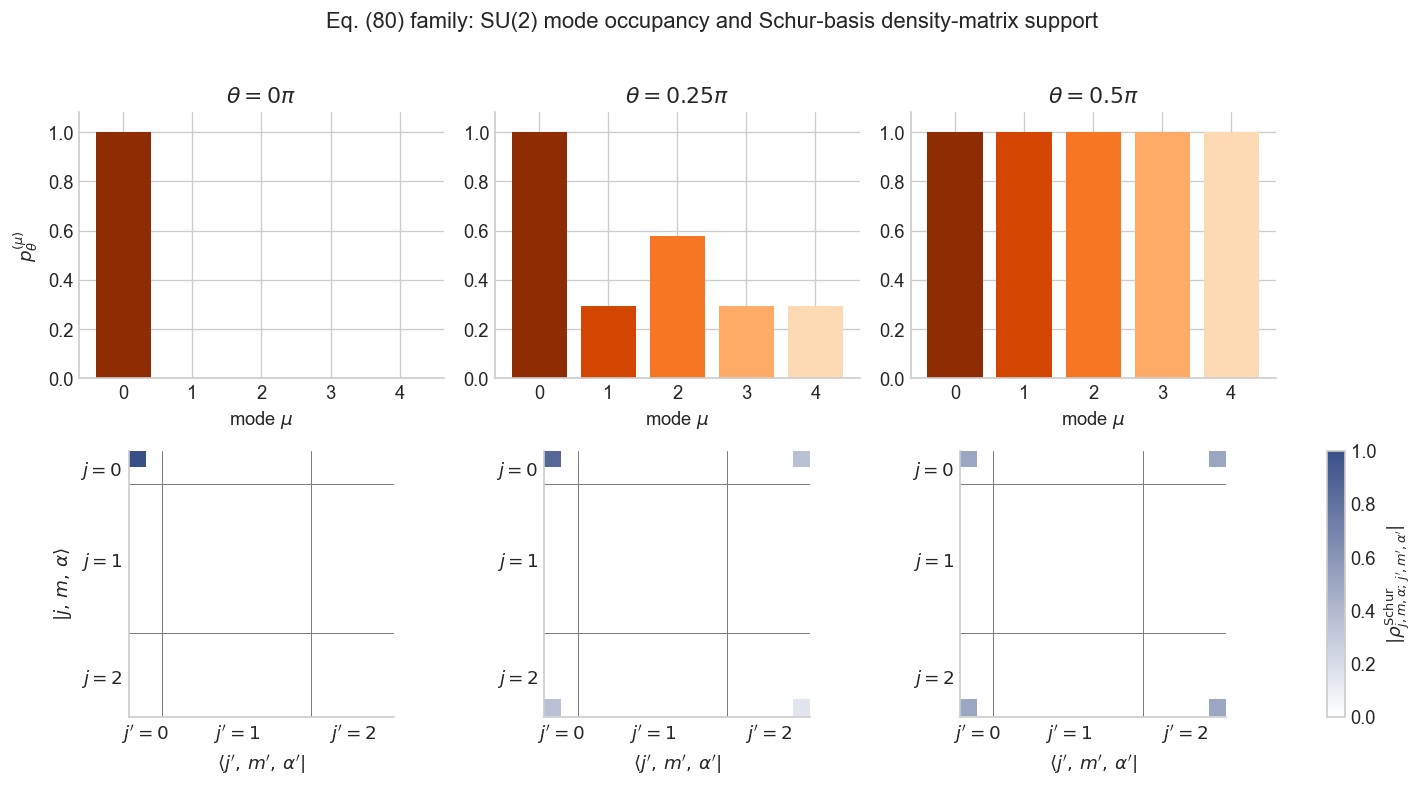

In [11]:
# Build the Eq. (80) family and compute its rescaled mode weights.
states_su2_eq80 = [
    np.outer(ket, ket.conj())
    for ket in (nu.su2_tilted_state(N_SU2, theta) for theta in THETAS_SU2)
]
mode_projections_eq80 = [
    {mu: nu.su2_operator_mode(state, mode_bases_su2[mu]) for mu in ranks_su2}
    for state in states_su2_eq80
]
raw_weights_eq80 = np.array([
    [float(np.sum(la.svdvals(projections[mu]))) for mu in ranks_su2]
    for projections in mode_projections_eq80
])
rescaled_weights_eq80 = raw_weights_eq80 / raw_weights_eq80[-1]

print("Rows: theta = 0, pi/4, pi/2;  columns: mu = 0, 1, ..., N_s")
print(rescaled_weights_eq80)

# Transform each density to the Schur basis so the (j, j') block
# structure becomes visually explicit.
schur_densities_eq80 = [
    nu.dagger(basis_su2) @ state @ basis_su2 for state in states_su2_eq80
]
density_vmax_eq80 = max(
    np.abs(state).max() for state in schur_densities_eq80
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6.4),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.05]},
)
axes[0, 3].axis("off")  # bar row has no colorbar

for column, (theta, state_schur, weights_theta) in enumerate(
    zip(THETAS_SU2, schur_densities_eq80, rescaled_weights_eq80)
):
    axes[0, column].bar(ranks_su2, weights_theta, color=rank_colors_su2)
    axes[0, column].set(
        title=fr"$\theta={theta / np.pi:.2g}\pi$",
        xlabel=r"mode $\mu$",
        ylabel=r"$p_\theta^{(\mu)}$" if column == 0 else None,
        ylim=(0, 1.08),
        xticks=ranks_su2,
    )

    im = axes[1, column].imshow(
        np.abs(state_schur),
        cmap=density_cmap_su2,
        vmin=0.0,
        vmax=density_vmax_eq80,
    )
    for boundary in sector_boundaries_su2:
        axes[1, column].axhline(boundary, color="#7C7C7C", linewidth=0.6)
        axes[1, column].axvline(boundary, color="#7C7C7C", linewidth=0.6)
    axes[1, column].set_xticks(sector_centers_su2)
    axes[1, column].set_xticklabels(sector_labels_su2_bra)
    axes[1, column].set_yticks(sector_centers_su2)
    axes[1, column].set_yticklabels(sector_labels_su2_ket)
    axes[1, column].set(
        xlabel=r"$\langle j',\,m',\,\alpha'|$",
        ylabel=r"$|j,\,m,\,\alpha\rangle$" if column == 0 else None,
    )
    axes[1, column].grid(False)

cbar = fig.colorbar(im, cax=axes[1, 3])
cbar.set_label(r"$|\rho^{\mathrm{Schur}}_{j,m,\alpha;\,j',m',\alpha'}|$")

fig.suptitle(
    "Eq. (80) family: SU(2) mode occupancy and Schur-basis density-matrix support",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Takeaway $SU(2)$

At $\theta=0$ the state is a product of singlets, invariant under
SU(2): only the $\mu=0$ mode is populated and every off-diagonal
Schur block is empty. Tilting each pair via a local $Y$-rotation on
one qubit smoothly leaks weight from $j_\text{pair}=0$ into
$j_\text{pair}=1$, and coupling $N_s/2$ pairs spreads the joint state
over every total-spin sector $j\in\{0,1,\dots,N_s/2\}$. The density
matrix picks up support in the Schur blocks $(j,j')$ with $j\ne j'$,
and those blocks in turn carry modes $|j-j'|\le\mu\le j+j'$. At
$\theta=\pi/2$ every allowed mode $\mu\in\{0,\dots,N_s\}$ is populated
with rescaled weight one, and the intermediate profile decays
monotonically with $\mu$ — mirroring the U(1) picture of Section 2
under the correspondence

$$
|\text{singlet product}\rangle \;\longleftrightarrow\; |0\rangle^{\otimes N_s},
\qquad
|\xi\rangle+|\phi^+\rangle \;\longleftrightarrow\; |+\rangle.
$$

Compared to the U(1) picture:

- The signed U(1) charge $\mu\in\mathbb Z$ is replaced by the SU(2)
  irrep label $\mu\in\{0,1,\dots,N_s\}$; both come from the
  irreducible tensor basis $T_\alpha^{(\mu,q)}$ of Eq. (44).
- Each SU(2) mode $\mu$ now carries an extra magnetic index
  $q\in\{-\mu,\dots,\mu\}$ (an internal irrep dimension), absent in
  the Abelian case where $d_\mu=1$.
- A single matrix element no longer carries one $\mu$: an entire
  *range* of modes lives in each Schur block, controlled by
  $|j-j'|\le\mu\le j+j'$.

As in the U(1) case, this mode decomposition is the raw material for
the symmetry Mpemba mechanism: distinct modes decay at distinct
rates under any SU(2)-covariant dynamics (Eq. 48). The covariant
Lindbladian is explored in `asymm_ex2.ipynb`; the exact SU(2)
brickwork circuit at the manuscript's Fig. 11 scale in
`asymm_ex5.ipynb`.
